Import data

In [1]:
import os
import pandas as pd

df = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), "data", "data_advice_fulltext.csv"))
docs = list(df["text"])
classes = list(df["gen"])

docs[:5]

['Consider each round carefully as it appears the same colours always go up against each other.\xa0 So yellow will always play against orange and purple against green.\xa0 Choose each colour in each round and remember who is best.\xa0 This will maximise your number of points.\xa0 Good luck.\xa0\xa0',
 'If the multiplier is 5, then choose the pointy hat (if they have different hats)If the multiplier is 1, then choose the round hat (if they have different hats)If they have the same hats and you have a choice of pink and brown, choose brown.\xa0If they have the same hats and you have a choice of yellow and red, you need to work out what colour the baske will be and choose that colour. That will alternate between red and yellow each go, so try and take notegood luck!',
 'The game is fantastic but requires you to think quickly and react.The features and characters is easy to use and move as well as the keys to play ths game is easy to each without hurting the fingers or hand.A lovely game. 

Pre-load embeddings

In [10]:
from sentence_transformers import SentenceTransformer

# Pre-calculate embeddings
#embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", use_auth_token=False)
embedding_model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2", use_auth_token=False)
embeddings = embedding_model.encode(docs, show_progress_bar=True)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Prepare topic fine-tuning models

In [11]:
from bertopic.representation import KeyBERTInspired
from bertopic.representation import MaximalMarginalRelevance

# The main representation of a topic
main_representation = KeyBERTInspired()

# Additional ways of representing a topic
aspect_model2 = [KeyBERTInspired(top_n_words=30), MaximalMarginalRelevance(diversity=.5)]

# Add all models together to be run in a single `fit`
representation_model = {
   "KeyBERT": main_representation,
   "MMR":  aspect_model2 
}

Train model

In [84]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer

# Hyperparameters

n_neighbors = 15
n_components = 10
random_state = 3
min_dist = 0.0
min_cluster_size = 10
min_df = 2
ngram_range = (1, 3)
top_n_words = 5
nr_topics = "auto"

# Setup different models

cluster_model = HDBSCAN(min_cluster_size=min_cluster_size, metric='euclidean', cluster_selection_method='eom', prediction_data=True)
vectorizer_model = CountVectorizer(stop_words="english", min_df=min_df, ngram_range=ngram_range)
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)
umap_model = UMAP(n_neighbors=n_neighbors, n_components=n_components, min_dist=min_dist, metric='cosine', random_state=random_state)

topic_model = BERTopic(

    # Pipeline models
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=cluster_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,

    # Hyperparameters
    top_n_words=top_n_words,
    n_gram_range=ngram_range,
    min_topic_size="auto", #use HDBSCAN
    verbose=True,
    nr_topics=nr_topics,

    # General parameters
    calculate_probabilities=True,
    language="english"
)

topics, probs = topic_model.fit_transform(docs, embeddings)

topic_model.get_topic_info()

2025-02-10 17:16:45,100 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-02-10 17:16:47,750 - BERTopic - Dimensionality - Completed ✓
2025-02-10 17:16:47,750 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-02-10 17:16:47,794 - BERTopic - Cluster - Completed ✓
2025-02-10 17:16:47,795 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-02-10 17:17:37,460 - BERTopic - Representation - Completed ✓
2025-02-10 17:17:37,461 - BERTopic - Topic reduction - Reducing number of topics
2025-02-10 17:18:02,956 - BERTopic - Topic reduction - Reduced number of topics from 8 to 5


,Topic,Count,Name,Representation,KeyBERT,MMR,Representative_Docs
0,-1,56,-1_mushrooms_gnomes_gnome_yellow,"[mushrooms, gnomes, gnome, yellow, red]","[value gnomes, number mushrooms, high value gn...","[value gnomes, number mushrooms, gnomes start,...",[There are two groups of gnomes based on their...
1,0,424,0_points_gnome_gnomes_colour,"[points, gnome, gnomes, colour, hat]","[gnomes, points, gnome, rewards, colours, gree...","[gnome, rewards, colours, game, random, hats, ...",[Every round shows a pair of gnomes. The gnome...
2,1,269,1_mushrooms_gnome_gnomes_colour,"[mushrooms, gnome, gnomes, colour, colours]","[gnomes mushrooms, number mushrooms, mushroom,...","[gnomes mushrooms, number mushrooms, mushrooms...",[You should try and test multiple colors to se...
3,2,165,2_basket_red_yellow_mushrooms,"[basket, red, yellow, mushrooms, gnomes]","[gnomes red basket, gnomes yellow basket, bask...","[gnomes red basket, basket mushrooms, colour b...",[There are two different colours of baskets in...
4,3,86,3_basket_red_yellow_gnomes,"[basket, red, yellow, gnomes, baskets]","[colour basket, basket colours, baskets red ye...","[colour basket, basket colours, baskets red ye...",[On the screen you will be presented with two ...


Evaluate model

In [85]:
from evaluation import evaluate_model
evaluate_model(topic_model, docs, topics, embeddings, topk=top_n_words)

(0.9135361470658067, 0.2774622138305743, 0.55, 0.49360308)

Visualization

In [86]:
topic_model.visualize_documents(docs)

In [87]:
topic_model.visualize_hierarchy()

Dynamic topic-modeling

In [ ]:
classes = list(df["gen"])

topics_over_time = topic_model.topics_over_time(docs, classes)

topic_model.visualize_topics_over_time(topics_over_time)

0it [00:00, ?it/s]

10it [00:00, 26.27it/s]


In [ ]:
topic_distr, _ = topic_model.approximate_distribution(docs)

100%|██████████| 1/1 [00:00<00:00,  2.99it/s]


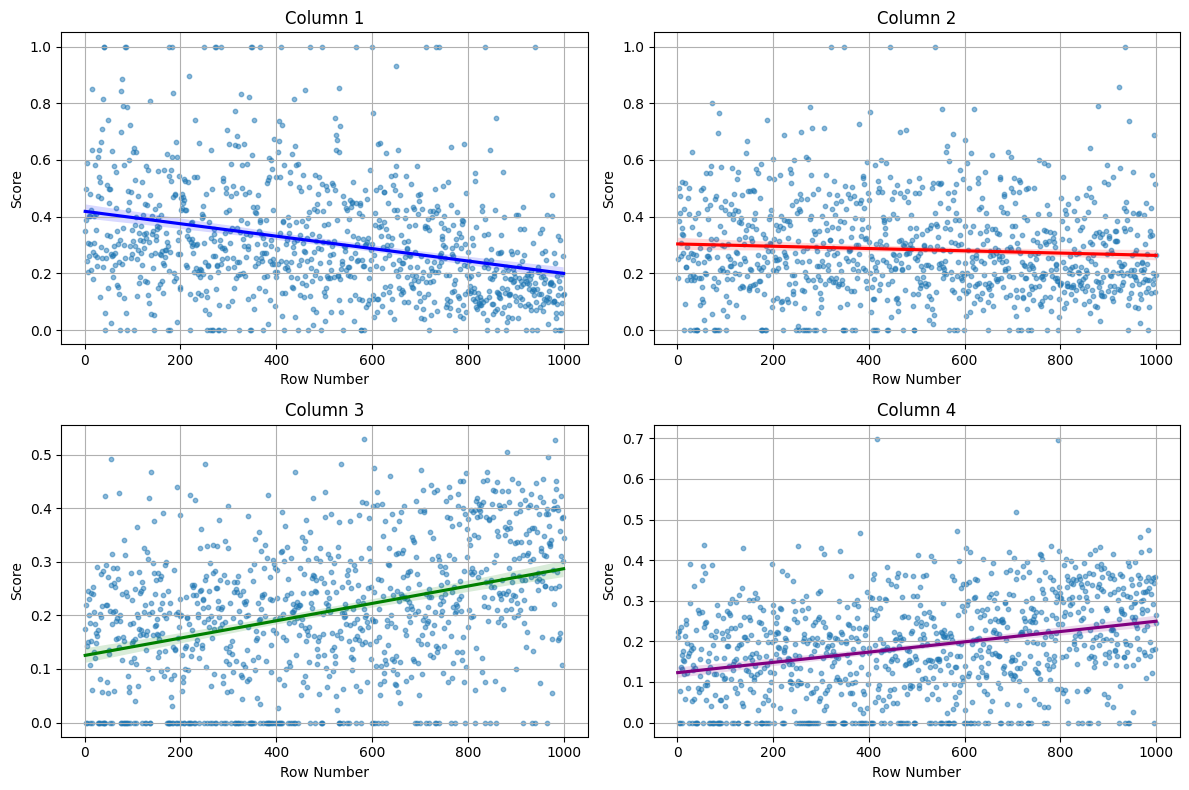

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create row numbers
row_numbers = np.arange(1, 1001)

# Define colors and labels for each column
colors = ['blue', 'red', 'green', 'purple']
labels = ['Column 1', 'Column 2', 'Column 3', 'Column 4']

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 2 rows, 2 columns
axes = axes.flatten()  # Flatten to easily iterate

# Plot each column separately
for i in range(4):
    sns.regplot(x=row_numbers, y=topic_distr[:, i], scatter_kws={'s': 10, 'alpha': 0.5}, 
                line_kws={'color': colors[i]}, ax=axes[i])
    axes[i].set_title(labels[i])
    axes[i].set_xlabel('Row Number')
    axes[i].set_ylabel('Score')
    axes[i].grid(True)

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
for i in topic_model.get_representative_docs(0):
    print(i)

It seems most of the game the gnomes with the longer hats do give more points. Not only the size of the hat that matters, but also the color. Pink long hat gnome gives more points than the blue one most of the time. Green small hat gnome gives more point than the orange small hat gnome. IT does switch up a little bit through each part. At the end of the last round, after the 4th break. It switches up at the end, so instead of choosing the colors or hat size gnomes, switch it up. So instead of choosing pink, go blue. Instead of green, go orange. Now between the long hat and small hat, the longer hats like I said do give more points, but remember when they seemed not to give a lot of points, switch to the small hat gnomes.
Every round shows a pair of gnomes. The gnomes are always shown in the same pairing; a gnome with a green hat is paired with a gnome with an orange hat, a gnome with a small yellow hat is paired with a gnome with a long purple hat, a gnome with a small red hat is paire